# Importance sampling

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1. Estimation of probability

- Estimating $p = \mathbb{P}[X \ge 6]$ where $X \sim \mathcal{N}(0,1) \sim f$

| Method | Sampling r.v | Estimator | Comment |
|--------|--------------|----------------|-------|
| Classic Monte-Carlo | $X_i \sim \mathcal{N}(0,1)$ | $$\hat{p} = \frac{1}{N}\sum_{i=1}^{N} \mathbf{1}_{\{X_i \ge 6\}}$$ | Naive method. Most samples contribute 0, computationally inefficient for rare events. |
| Importance Sampling | $Y_i = 6 + T_i$, where $T_i \sim \text{Exp}(1)$ | $$\hat{p}_{IS1} = \frac{1}{N}\sum_{i=1}^{N} \frac{f(Y_i)}{g_1(Y_i)}$$ | Samples drawn from a proposal $g_1$ concentrated in the rare event area. All samples contribute to the estimate. |
| Importance Sampling | $Y_i \sim \mathcal{N}(6,1)$ | $$\hat{p}_{IS2} = \frac{1}{N}\sum_{i=1}^{N} \frac{f(Y_i)}{g_2(Y_i)} \mathbf{1}_{\{Y_i \ge 6\}}$$ | Proposal distribution centered at the event boundary. Half the samples contributing, but massively improves compared to the classic method. |

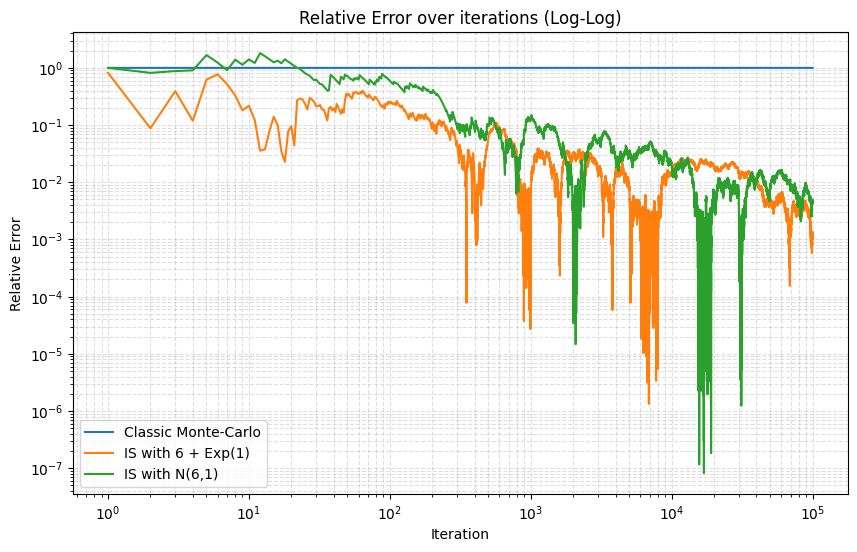

True probability: 9.866e-10
Final Rel. Error (Naive): 100.00%
Final Rel. Error (Exp): 0.10%
Final Rel. Error (Normal): 0.43%


In [ ]:
rng = np.random.default_rng(0)
N_samples = 100_000
iterations = np.arange(1, N_samples + 1)
p_true = norm.sf(6)

# Naive Monte Carlo
X_naive = rng.normal(loc=0, scale=1, size=N_samples)
p_monte_carlo_path = np.cumsum(X_naive >= 6) / iterations

# IS with shifted exponential: Y = 6 + T, T ~ Exp(1)
def quotient_exponential(y):
    return 1/np.sqrt(2 * np.pi) * np.exp(-y**2 / 2 + y - 6)

T = rng.exponential(scale=1.0, size=N_samples)
Y_exponential = T + 6
p_importance_exponential_path = np.cumsum(quotient_exponential(Y_exponential)) / iterations

# IS with shifted normal: Y ~ N(6, 1)
def quotient_normal(y):
    return np.exp(18 - 6 * y) * (y >= 6).astype(float)

Y_normal = rng.normal(loc=6, scale=1, size=N_samples)
p_importance_normal_path = np.cumsum(quotient_normal(Y_normal)) / iterations

# Relative Error: |estimate - true| / true
error_series = {
    "Classic Monte-Carlo": np.abs(p_monte_carlo_path - p_true) / p_true,
    "IS with 6 + Exp(1)": np.abs(p_importance_exponential_path - p_true) / p_true,
    "IS with N(6,1)": np.abs(p_importance_normal_path - p_true) / p_true,
}

plt.figure(figsize=(10, 6))
for label, values in error_series.items():
    # Mask zeros/nans for log plot
    valid = values > 0
    plt.plot(iterations[valid], values[valid], label=label)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Relative Error")
plt.title("Relative Error over iterations (Log-Log)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()


print(f"True probability: {p_true:.3e}")
print(f"Final Rel. Error (Naive): {error_series['Classic Monte-Carlo'][-1]:.2%}")
print(f"Final Rel. Error (Exp): {error_series['IS with 6 + Exp(1)'][-1]:.2%}")
print(f"Final Rel. Error (Normal): {error_series['IS with N(6,1)'][-1]:.2%}")

- Confidence intervals

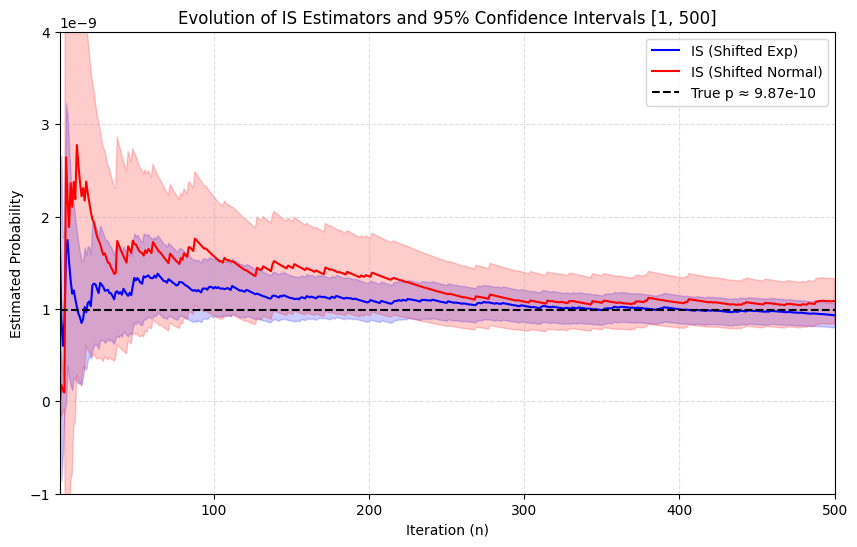

In [4]:
N_ci = 500
n_vals = np.arange(1, N_ci + 1)
z_alpha = 1.96 # 95% CI

W_exp = quotient_exponential(Y_exponential[:N_ci])
W_norm = quotient_normal(Y_normal[:N_ci])

p_hat_exp = np.cumsum(W_exp) / n_vals
p_hat_norm = np.cumsum(W_norm) / n_vals

var_exp = np.array([np.var(W_exp[:i], ddof=1) if i > 1 else 0 for i in range(1, N_ci + 1)])
var_norm = np.array([np.var(W_norm[:i], ddof=1) if i > 1 else 0 for i in range(1, N_ci + 1)])

ci_exp = z_alpha * np.sqrt(var_exp / n_vals)
ci_norm = z_alpha * np.sqrt(var_norm / n_vals)

plt.figure(figsize=(10, 6))

plt.plot(n_vals, p_hat_exp, label='IS (Shifted Exp)', color='blue')
plt.fill_between(n_vals, p_hat_exp - ci_exp, p_hat_exp + ci_exp, color='blue', alpha=0.2)

plt.plot(n_vals, p_hat_norm, label='IS (Shifted Normal)', color='red')
plt.fill_between(n_vals, p_hat_norm - ci_norm, p_hat_norm + ci_norm, color='red', alpha=0.2)

plt.axhline(y=p_true, color='black', linestyle='--', label=f'True p ≈ {p_true:.2e}')

plt.xlabel('Iteration (n)')
plt.ylabel('Estimated Probability')
plt.title('Evolution of IS Estimators and 95% Confidence Intervals [1, 500]')
plt.xlim(1, 500)
plt.ylim(-1e-9, 4e-9) # Fixed limits to ignore massive early-variance spikes
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()